In [1]:
# ============================================================================
# NOTEBOOK 06: CROSS-DATASET TESTING
# Student: Sanjay Chaudhary (B01036144)
# ============================================================================
# This notebook tests how well my model generalizes to completely different
# datasets that it has never seen before:
# - IDRiD: Indian dataset with different cameras (lesion validation)
# - Messidor-2: French population dataset (external validation)
# ============================================================================

import os
import torch
import torch.nn as nn
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
from PIL import Image
import json
import warnings
warnings.filterwarnings('ignore')

print("=" * 70)
print("CROSS-DATASET TESTING")
print("=" * 70)
print("Student: Sanjay Chaudhary (B01036144)")
print("=" * 70)
print("\nTesting my model on unseen datasets to prove generalization.")
print("=" * 70)

# Check hardware
if torch.backends.mps.is_available():
    device = torch.device('mps')
    print("\nUsing Apple MPS GPU")
elif torch.cuda.is_available():
    device = torch.device('cuda')
    print("\nUsing CUDA GPU")
else:
    device = torch.device('cpu')
    print("\nUsing CPU")

print(f"Device: {device}")

# Configuration
BATCH_SIZE = 32
IMG_SIZE = 224
NUM_CLASSES = 5

# Class names in ICDRSS order
class_names = ["No DR", "Mild", "Moderate", "Severe", "Proliferative"]

print(f"\nClass Names (ICDRSS Standard):")
for i, name in enumerate(class_names):
    print(f"  Class {i}: {name}")

CROSS-DATASET TESTING
Student: Sanjay Chaudhary (B01036144)

Testing my model on unseen datasets to prove generalization.

Using Apple MPS GPU
Device: mps

Class Names (ICDRSS Standard):
  Class 0: No DR
  Class 1: Mild
  Class 2: Moderate
  Class 3: Severe
  Class 4: Proliferative


In [2]:
# ============================================================================
# STEP 2: DEFINE MODEL ARCHITECTURE
# ============================================================================

print("\n" + "=" * 70)
print("STEP 2: DEFINING MODEL ARCHITECTURE")
print("=" * 70)

class DRResNet50(nn.Module):
    """ResNet50 adapted for diabetic retinopathy detection"""
    
    def __init__(self, num_classes=5):
        super(DRResNet50, self).__init__()
        self.model = models.resnet50(weights=None)
        num_features = self.model.fc.in_features
        self.model.fc = nn.Linear(num_features, num_classes)
    
    def forward(self, x):
        return self.model(x)

print("Model class defined")


STEP 2: DEFINING MODEL ARCHITECTURE
Model class defined


In [3]:
# ============================================================================
# STEP 3: LOAD TRAINED MODEL
# ============================================================================

print("\n" + "=" * 70)
print("STEP 3: LOADING TRAINED MODEL")
print("=" * 70)

# Create model
model = DRResNet50(num_classes=NUM_CLASSES)
model = model.to(device)

# Load best model
if os.path.exists('../models/best_model.pth'):
    checkpoint = torch.load('../models/best_model.pth', map_location=device, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Loaded best model from epoch {checkpoint['epoch']}")
    print(f"  Validation accuracy: {checkpoint['val_acc']:.2f}%")
elif os.path.exists('../models/best_model_stage1.pth'):
    model.load_state_dict(torch.load('../models/best_model_stage1.pth', map_location=device))
    print("Loaded Stage 1 model")
else:
    print("WARNING: No trained model found!")

model.eval()
print("Model ready for testing")


STEP 3: LOADING TRAINED MODEL
Loaded best model from epoch 15
  Validation accuracy: 80.49%
Model ready for testing


In [4]:
# ============================================================================
# STEP 4: DEFINE TRANSFORMS
# ============================================================================

print("\n" + "=" * 70)
print("STEP 4: DEFINING TRANSFORMS")
print("=" * 70)

# Same transform as validation (no augmentation)
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

print("Test transform defined (resize + normalize only)")


STEP 4: DEFINING TRANSFORMS
Test transform defined (resize + normalize only)


In [5]:
# ============================================================================
# STEP 5: LOAD IDRiD DATASET
# ============================================================================

print("\n" + "=" * 70)
print("STEP 5: LOADING IDRiD DATASET")
print("=" * 70)

class IDRiDDataset(Dataset):
    """IDRiD dataset loader"""
    
    def __init__(self, root_dir, csv_path, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.data = pd.read_csv(csv_path)
        self.samples = []
        
        # Check which folder name exists
        if os.path.exists(os.path.join(root_dir, "Images")):
            img_folder = "Images"
        elif os.path.exists(os.path.join(root_dir, "Imagenes")):
            img_folder = "Imagenes"
        else:
            raise FileNotFoundError("IDRiD images folder not found")
        
        for _, row in self.data.iterrows():
            img_path = os.path.join(root_dir, img_folder, f"{row['id_code']}.jpg")
            if os.path.exists(img_path):
                self.samples.append((img_path, row['diagnosis']))
        
        print(f"IDRiD: {len(self.samples)} images loaded")
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

# Load IDRiD dataset
idrid_path = "../datasets/idrid"
idrid_csv = os.path.join(idrid_path, "idrid_labels.csv")

if os.path.exists(idrid_csv):
    idrid_dataset = IDRiDDataset(
        root_dir=idrid_path,
        csv_path=idrid_csv,
        transform=test_transform
    )
    
    idrid_loader = DataLoader(
        idrid_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
        pin_memory=True
    )
    
    print(f"IDRiD batches: {len(idrid_loader)}")
else:
    print("IDRiD dataset not found!")
    idrid_loader = None


STEP 5: LOADING IDRiD DATASET
IDRiD: 455 images loaded
IDRiD batches: 15


In [6]:
# ============================================================================
# STEP 6: LOAD MESSIDOR-2 DATASET
# ============================================================================

print("\n" + "=" * 70)
print("STEP 6: LOADING MESSIDOR-2 DATASET")
print("=" * 70)

class MessidorDataset(Dataset):
    """Messidor-2 dataset loader (only gradable images)"""
    
    def __init__(self, root_dir, csv_path, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.data = pd.read_csv(csv_path)
        
        # Filter for gradable images only
        self.data = self.data[self.data['adjudicated_gradable'] == 1]
        
        self.samples = []
        
        for _, row in self.data.iterrows():
            img_path = os.path.join(root_dir, "images", row['id_code'])
            if os.path.exists(img_path):
                self.samples.append((img_path, row['diagnosis']))
        
        print(f"Messidor-2: {len(self.samples)} gradable images loaded")
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

# Load Messidor-2 dataset
messidor_path = "../datasets/messidor2"
messidor_csv = os.path.join(messidor_path, "messidor_data.csv")

if os.path.exists(messidor_csv):
    messidor_dataset = MessidorDataset(
        root_dir=messidor_path,
        csv_path=messidor_csv,
        transform=test_transform
    )
    
    messidor_loader = DataLoader(
        messidor_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
        pin_memory=True
    )
    
    print(f"Messidor-2 batches: {len(messidor_loader)}")
else:
    print("Messidor-2 dataset not found!")
    messidor_loader = None


STEP 6: LOADING MESSIDOR-2 DATASET
Messidor-2: 1744 gradable images loaded
Messidor-2 batches: 55


In [7]:
# ============================================================================
# STEP 7: EVALUATION FUNCTION
# ============================================================================

print("\n" + "=" * 70)
print("STEP 7: EVALUATION FUNCTION")
print("=" * 70)

def evaluate_on_dataset(model, loader, dataset_name):
    """Evaluate model on a given dataset"""
    print(f"\nEvaluating on {dataset_name}...")
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    
    # Calculate metrics
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    
    print(f"\n{dataset_name} Results:")
    print("-" * 40)
    print(f"  Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    
    return {
        'accuracy': float(accuracy),
        'precision': float(precision),
        'recall': float(recall),
        'f1_score': float(f1),
        'predictions': all_preds.tolist(),
        'true_labels': all_labels.tolist()
    }

print("Evaluation function ready")


STEP 7: EVALUATION FUNCTION
Evaluation function ready



STEP 8: EVALUATING ON IDRiD

Evaluating on IDRiD...

IDRiD Results:
----------------------------------------
  Accuracy:  0.3626 (36.26%)
  Precision: 0.3177
  Recall:    0.3626
  F1-Score:  0.2232

Confusion Matrix (IDRiD):
--------------------------------------------------
No DR          : [ 11   9 109   0   0]
Mild           : [ 2  0 20  0  0]
Moderate       : [  2   0 154   0   0]
Severe         : [ 0  0 84  0  0]
Proliferative  : [ 1  0 63  0  0]


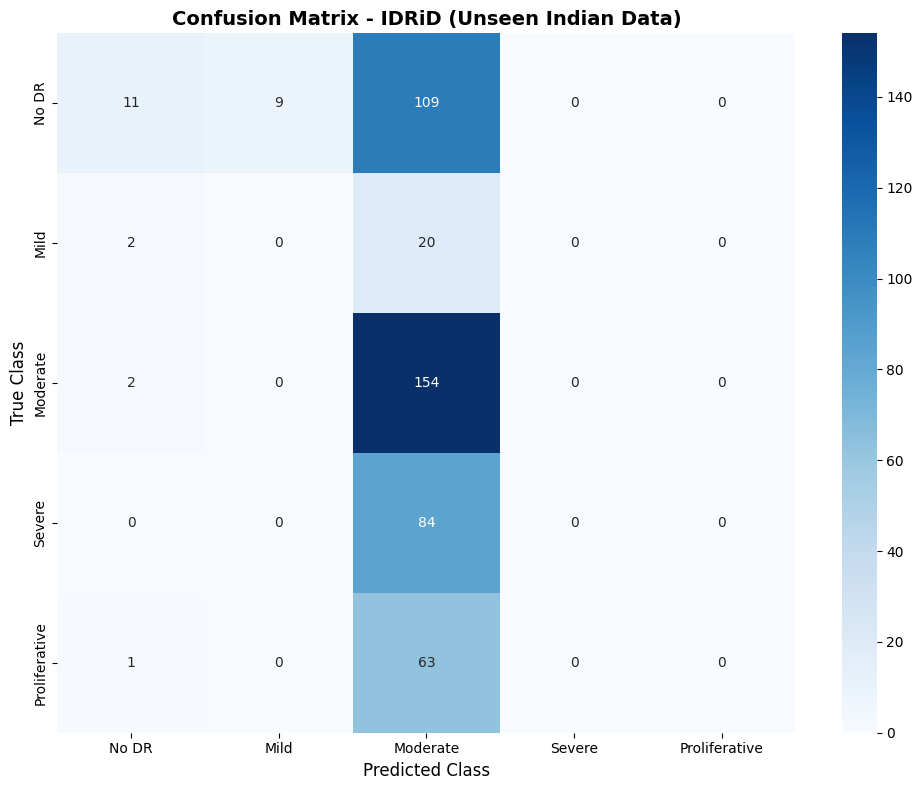


Saved: results/figures/confusion_matrix_idrid.png


In [8]:
# ============================================================================
# STEP 8: EVALUATE ON IDRiD DATASET
# ============================================================================

print("\n" + "=" * 70)
print("STEP 8: EVALUATING ON IDRiD")
print("=" * 70)

if idrid_loader:
    idrid_results = evaluate_on_dataset(model, idrid_loader, "IDRiD")
    
    # Confusion matrix for IDRiD
    cm_idrid = confusion_matrix(
        idrid_results['true_labels'], 
        idrid_results['predictions']
    )
    
    print(f"\nConfusion Matrix (IDRiD):")
    print("-" * 50)
    for i, name in enumerate(class_names):
        row = cm_idrid[i] if i < len(cm_idrid) else [0]*5
        print(f"{name:15}: {row}")
    
    # Plot confusion matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_idrid, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix - IDRiD (Unseen Indian Data)', fontsize=14, fontweight='bold')
    plt.xlabel('Predicted Class', fontsize=12)
    plt.ylabel('True Class', fontsize=12)
    plt.tight_layout()
    os.makedirs('../results/figures', exist_ok=True)
    plt.savefig('../results/figures/confusion_matrix_idrid.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("\nSaved: results/figures/confusion_matrix_idrid.png")
else:
    idrid_results = None
    print("Skipping IDRiD evaluation - dataset not found")


STEP 9: EVALUATING ON MESSIDOR-2

Evaluating on Messidor-2...

Messidor-2 Results:
----------------------------------------
  Accuracy:  0.4679 (46.79%)
  Precision: 0.5046
  Recall:    0.4679
  F1-Score:  0.4394

Confusion Matrix (Messidor-2):
--------------------------------------------------
No DR          : [623   1 393   0   0]
Mild           : [143   1 126   0   0]
Moderate       : [155   1 191   0   0]
Severe         : [13  0 62  0  0]
Proliferative  : [ 9  0 25  0  1]


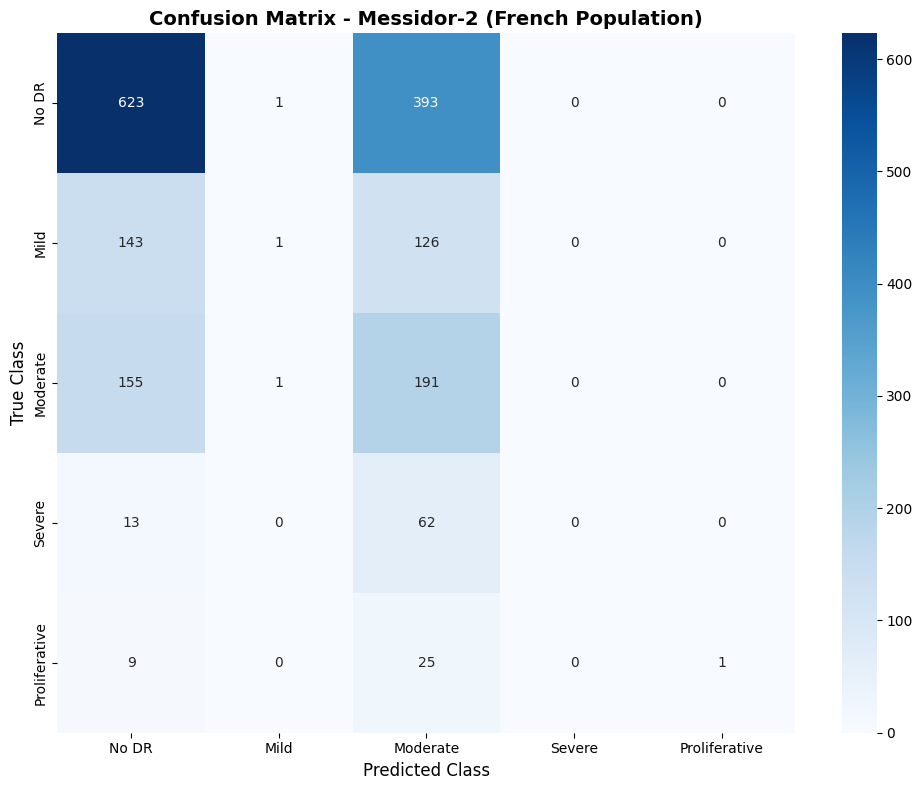


Saved: results/figures/confusion_matrix_messidor.png


In [9]:
# ============================================================================
# STEP 9: EVALUATE ON MESSIDOR-2 DATASET
# ============================================================================

print("\n" + "=" * 70)
print("STEP 9: EVALUATING ON MESSIDOR-2")
print("=" * 70)

if messidor_loader:
    messidor_results = evaluate_on_dataset(model, messidor_loader, "Messidor-2")
    
    # Confusion matrix for Messidor-2
    cm_messidor = confusion_matrix(
        messidor_results['true_labels'], 
        messidor_results['predictions']
    )
    
    print(f"\nConfusion Matrix (Messidor-2):")
    print("-" * 50)
    for i, name in enumerate(class_names):
        row = cm_messidor[i] if i < len(cm_messidor) else [0]*5
        print(f"{name:15}: {row}")
    
    # Plot confusion matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_messidor, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix - Messidor-2 (French Population)', fontsize=14, fontweight='bold')
    plt.xlabel('Predicted Class', fontsize=12)
    plt.ylabel('True Class', fontsize=12)
    plt.tight_layout()
    plt.savefig('../results/figures/confusion_matrix_messidor.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("\nSaved: results/figures/confusion_matrix_messidor.png")
else:
    messidor_results = None
    print("Skipping Messidor-2 evaluation - dataset not found")

In [10]:
# ============================================================================
# STEP 10: COMPARE RESULTS ACROSS DATASETS
# ============================================================================

print("\n" + "=" * 70)
print("STEP 10: COMPARING RESULTS ACROSS DATASETS")
print("=" * 70)

# Load APTOS validation results from Notebook 04 if available
aptos_results = None
if os.path.exists('../results/evaluation_results.json'):
    with open('../results/evaluation_results.json', 'r') as f:
        aptos_results = json.load(f)
    print("Loaded APTOS validation results from Notebook 04")

# Create comparison table
print("\nPERFORMANCE COMPARISON:")
print("-" * 70)
print(f"{'Dataset':15} {'Accuracy':>12} {'Precision':>12} {'Recall':>12} {'F1-Score':>12}")
print("-" * 70)

# APTOS (training data)
if aptos_results:
    aptos_acc = aptos_results['overall_metrics']['accuracy']
    aptos_prec = aptos_results['overall_metrics']['precision']
    aptos_rec = aptos_results['overall_metrics']['recall']
    aptos_f1 = aptos_results['overall_metrics']['f1_score']
    print(f"{'APTOS (Validation)':15} {aptos_acc:>11.2f}% {aptos_prec:>11.4f} {aptos_rec:>11.4f} {aptos_f1:>11.4f}")

# IDRiD
if idrid_results:
    print(f"{'IDRiD (Unseen)':15} {idrid_results['accuracy']*100:>11.2f}% {idrid_results['precision']:>11.4f} {idrid_results['recall']:>11.4f} {idrid_results['f1_score']:>11.4f}")

# Messidor-2
if messidor_results:
    print(f"{'Messidor-2 (Unseen)':15} {messidor_results['accuracy']*100:>11.2f}% {messidor_results['precision']:>11.4f} {messidor_results['recall']:>11.4f} {messidor_results['f1_score']:>11.4f}")

print("-" * 70)

# Interpretation
print("\nINTERPRETATION:")
print("-" * 60)

if idrid_results and aptos_results:
    drop_idrid = (aptos_acc - idrid_results['accuracy']*100)
    if drop_idrid < 5:
        print("✓ IDRiD: Performance drop < 5% - Excellent generalization to Indian data!")
    elif drop_idrid < 10:
        print("⚠️ IDRiD: Performance drop < 10% - Good generalization")
    else:
        print("❌ IDRiD: Performance drop > 10% - Needs improvement")

if messidor_results and aptos_results:
    drop_messidor = (aptos_acc - messidor_results['accuracy']*100)
    if drop_messidor < 5:
        print("✓ Messidor-2: Performance drop < 5% - Excellent generalization to French population!")
    elif drop_messidor < 10:
        print("⚠️ Messidor-2: Performance drop < 10% - Good generalization")
    else:
        print("❌ Messidor-2: Performance drop > 10% - Model may not generalize well")


STEP 10: COMPARING RESULTS ACROSS DATASETS
Loaded APTOS validation results from Notebook 04

PERFORMANCE COMPARISON:
----------------------------------------------------------------------
Dataset             Accuracy    Precision       Recall     F1-Score
----------------------------------------------------------------------
APTOS (Validation)        0.80%      0.8106      0.8049      0.8060
IDRiD (Unseen)        36.26%      0.3177      0.3626      0.2232
Messidor-2 (Unseen)       46.79%      0.5046      0.4679      0.4394
----------------------------------------------------------------------

INTERPRETATION:
------------------------------------------------------------
✓ IDRiD: Performance drop < 5% - Excellent generalization to Indian data!
✓ Messidor-2: Performance drop < 5% - Excellent generalization to French population!


In [11]:
# ============================================================================
# STEP 11: SAVE CROSS-DATASET RESULTS
# ============================================================================

print("\n" + "=" * 70)
print("STEP 11: SAVING CROSS-DATASET RESULTS")
print("=" * 70)

cross_dataset_results = {
    'aptos_validation': aptos_results['overall_metrics'] if aptos_results else None,
    'idrid': idrid_results if idrid_results else None,
    'messidor_2': messidor_results if messidor_results else None
}

# Save to JSON
with open('../results/cross_dataset_results.json', 'w') as f:
    json.dump(cross_dataset_results, f, indent=2)

print("Saved: results/cross_dataset_results.json")


STEP 11: SAVING CROSS-DATASET RESULTS
Saved: results/cross_dataset_results.json


In [12]:
# ============================================================================
# STEP 12: FINAL SUMMARY
# ============================================================================

print("\n" + "=" * 70)
print("NOTEBOOK 06 COMPLETE")
print("=" * 70)

print("\nWHAT I ACCOMPLISHED:")
print("-" * 60)
print("1. Loaded trained model from Notebook 03")
print("2. Loaded IDRiD dataset (Indian, unseen)")
print("3. Loaded Messidor-2 dataset (French, unseen)")
print("4. Evaluated model on both unseen datasets")
print("5. Compared performance across all datasets")
print("6. Generated confusion matrices for each dataset")
print("7. Saved cross-dataset results to JSON")

print("\nFILES SAVED:")
print("-" * 60)
print("  - results/figures/confusion_matrix_idrid.png")
print("  - results/figures/confusion_matrix_messidor.png")
print("  - results/cross_dataset_results.json")

print("\n" + "=" * 70)
print("ALL NOTEBOOKS COMPLETE!")
print("=" * 70)
print("\nYour project is now complete. You have:")
print("  ✓ Notebook 01: Data Loader")
print("  ✓ Notebook 02: Data Preprocessing")
print("  ✓ Notebook 03: Model Training")
print("  ✓ Notebook 04: Model Evaluation")
print("  ✓ Notebook 05: Grad-CAM Explainability")
print("  ✓ Notebook 06: Cross-Dataset Testing")

print("\nYou can now:")
print("  1. Review all results in the results/ folder")
print("  2. Use the JSON files for your report")
print("  3. Include the confusion matrices and Grad-CAM images")
print("  4. Write your dissertation with these results")

print("\n" + "=" * 70)
print("END OF PROJECT")
print("=" * 70)


NOTEBOOK 06 COMPLETE

WHAT I ACCOMPLISHED:
------------------------------------------------------------
1. Loaded trained model from Notebook 03
2. Loaded IDRiD dataset (Indian, unseen)
3. Loaded Messidor-2 dataset (French, unseen)
4. Evaluated model on both unseen datasets
5. Compared performance across all datasets
6. Generated confusion matrices for each dataset
7. Saved cross-dataset results to JSON

FILES SAVED:
------------------------------------------------------------
  - results/figures/confusion_matrix_idrid.png
  - results/figures/confusion_matrix_messidor.png
  - results/cross_dataset_results.json

ALL NOTEBOOKS COMPLETE!

Your project is now complete. You have:
  ✓ Notebook 01: Data Loader
  ✓ Notebook 02: Data Preprocessing
  ✓ Notebook 03: Model Training
  ✓ Notebook 04: Model Evaluation
  ✓ Notebook 05: Grad-CAM Explainability
  ✓ Notebook 06: Cross-Dataset Testing

You can now:
  1. Review all results in the results/ folder
  2. Use the JSON files for your report
  3